In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
#loading the datasets
from google.colab import files

uploaded = files.upload()

Saving lifecycle_events.csv to lifecycle_events.csv
Saving product_categories.csv to product_categories.csv
Saving products.csv to products.csv
Saving regions.csv to regions.csv
Saving submission_targets.csv to submission_targets.csv
Saving submissions.csv to submissions.csv


In [5]:
#reading the datasets
products = pd.read_csv("/content/products.csv")
submissions = pd.read_csv("/content/submissions.csv")
lifecycle_events = pd.read_csv("/content/lifecycle_events.csv")
regions = pd.read_csv("/content/regions.csv")
product_categories = pd.read_csv("/content/product_categories.csv")
submission_targets = pd.read_csv("/content/submission_targets.csv")


In [6]:
print("Products:", products.shape)
print("Submissions:", submissions.shape)
print("Lifecycle Events:", lifecycle_events.shape)
print("Regions:", regions.shape)
print("Product Categories:", product_categories.shape)
print("Submission Targets:", submission_targets.shape)

Products: (15000, 8)
Submissions: (30000, 13)
Lifecycle Events: (180000, 9)
Regions: (8, 3)
Product Categories: (6, 2)
Submission Targets: (4, 2)


In [7]:
submissions.head()

,Submission_ID,Product_ID,Region_ID,Submission_Type,Submission_Date,Approval_Date,Submission_Status,Priority,Risk_Score,Risk_Category,Review_Days,Target_Review_Days,Submission_Delayed
0,500001,102969,5,Product Extension,2024-02-07,NaN,Under Review,Medium,34,Low,85.1,90,No
1,500002,114850,6,New Product,2025-06-17,NaN,Under Review,High,47,Medium,97.2,120,No
2,500003,100622,8,Label Update,2025-07-10,2025-08-23 02:24:00,Approved,Low,18,Low,44.1,60,No
3,500004,104445,1,New Product,2025-03-14,2025-06-29 02:24:00,Approved,Medium,49,Medium,107.1,120,No
4,500005,108495,3,Post-Market Update,2025-03-27,2025-05-18 12:00:00,Delayed,High,47,Medium,52.5,45,Yes


In [8]:
submissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Submission_ID       30000 non-null  int64  
 1   Product_ID          30000 non-null  int64  
 2   Region_ID           30000 non-null  int64  
 3   Submission_Type     30000 non-null  object 
 4   Submission_Date     30000 non-null  object 
 5   Approval_Date       22082 non-null  object 
 6   Submission_Status   30000 non-null  object 
 7   Priority            30000 non-null  object 
 8   Risk_Score          30000 non-null  int64  
 9   Risk_Category       30000 non-null  object 
 10  Review_Days         30000 non-null  float64
 11  Target_Review_Days  30000 non-null  int64  
 12  Submission_Delayed  30000 non-null  object 
dtypes: float64(1), int64(5), object(7)
memory usage: 3.0+ MB


In [9]:
#converting date columns
submissions["Submission_Date"] = pd.to_datetime(
    submissions["Submission_Date"]
)

submissions["Approval_Date"] = pd.to_datetime(
    submissions["Approval_Date"]
)

print("Date columns converted successfully")
print(submissions[["Submission_Date", "Approval_Date"]].dtypes)

Date columns converted successfully
Submission_Date    datetime64[ns]
Approval_Date      datetime64[ns]
dtype: object


In [10]:
#converting submission delayed to Boolean
submissions["Submission_Delayed"] = (
    submissions["Submission_Delayed"] == "Yes"
)

print(submissions["Submission_Delayed"].value_counts())
print(submissions["Submission_Delayed"].dtype)

Submission_Delayed
False    22331
True      7669
Name: count, dtype: int64
bool


In [11]:
#checking missing values
missing = submissions.isna().sum()

print(missing)

Submission_ID            0
Product_ID               0
Region_ID                0
Submission_Type          0
Submission_Date          0
Approval_Date         7918
Submission_Status        0
Priority                 0
Risk_Score               0
Risk_Category            0
Review_Days              0
Target_Review_Days       0
Submission_Delayed       0
dtype: int64


In [12]:
#creating variable columns for analysis
submissions["Review_Variance_Days"] = (
    submissions["Review_Days"] - submissions["Target_Review_Days"]
)

submissions["Review_Within_Target"] = (
    submissions["Review_Days"] <= submissions["Target_Review_Days"]
)

submissions[[
    "Review_Days",
    "Target_Review_Days",
    "Review_Variance_Days",
    "Review_Within_Target"
]].head()

,Review_Days,Target_Review_Days,Review_Variance_Days,Review_Within_Target
0,85.1,90,-4.9,True
1,97.2,120,-22.8,True
2,44.1,60,-15.9,True
3,107.1,120,-12.9,True
4,52.5,45,7.5,False


In [13]:
#descriptive stats
submissions[
    [
        "Risk_Score",
        "Review_Days",
        "Target_Review_Days",
        "Review_Variance_Days"
    ]
].describe()

,Risk_Score,Review_Days,Target_Review_Days,Review_Variance_Days
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,42.777500,74.611547,86.383000,-11.771453
std,18.677272,23.885553,28.544342,17.792893
min,5.000000,5.000000,45.000000,-78.300000
25%,29.000000,56.900000,60.000000,-24.000000
50%,41.000000,75.100000,90.000000,-11.900000
75%,55.000000,92.600000,120.000000,0.400000
max,95.000000,150.800000,120.000000,56.200000


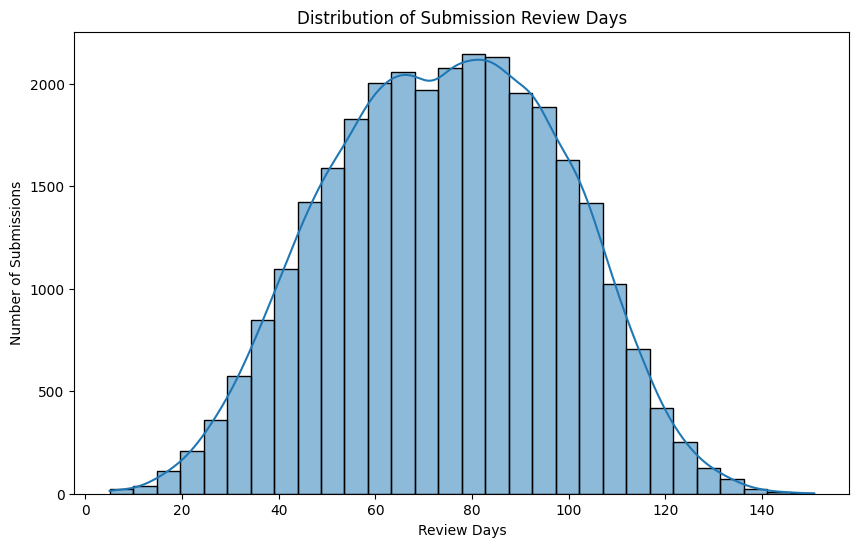

In [14]:
#Review days distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    submissions["Review_Days"],
    bins=30,
    kde=True
)

plt.title("Distribution of Submission Review Days")
plt.xlabel("Review Days")
plt.ylabel("Number of Submissions")

plt.show()

In [15]:
#Analyse review performance by submission type
review_by_type = (
    submissions
    .groupby("Submission_Type")["Review_Days"]
    .mean()
    .sort_values(ascending=False)
)

print(review_by_type)

Submission_Type
New Product           96.661436
Product Extension     76.981637
Unknown               76.642500
Label Update          57.209055
Post-Market Update    47.569866
Name: Review_Days, dtype: float64


In [16]:
#average review variance by submission type
variance_by_type = (
    submissions
    .groupby("Submission_Type")["Review_Variance_Days"]
    .mean()
    .sort_values(ascending=False)
)

print(variance_by_type)

Submission_Type
Post-Market Update     2.569866
Label Update          -2.790945
Unknown               -9.795000
Product Extension    -13.018363
New Product          -23.338564
Name: Review_Variance_Days, dtype: float64


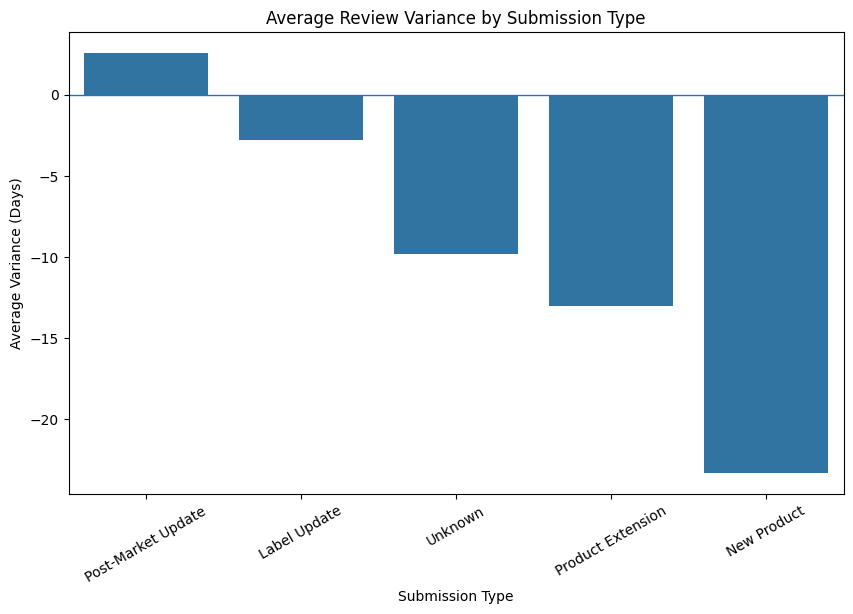

In [17]:
#Visualise review variance by submission type
plt.figure(figsize=(10, 6))

sns.barplot(
    x=variance_by_type.index,
    y=variance_by_type.values
)

plt.axhline(0, linewidth=1)

plt.title("Average Review Variance by Submission Type")
plt.xlabel("Submission Type")
plt.ylabel("Average Variance (Days)")
plt.xticks(rotation=30)

plt.show()

In [18]:
#Analyse delay rates by submission type
delay_by_type = (
    submissions
    .groupby("Submission_Type")["Submission_Delayed"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(delay_by_type)

Submission_Type
Post-Market Update    56.339193
Label Update          42.654758
Unknown               31.250000
Product Extension     18.551822
New Product            5.740211
Name: Submission_Delayed, dtype: float64


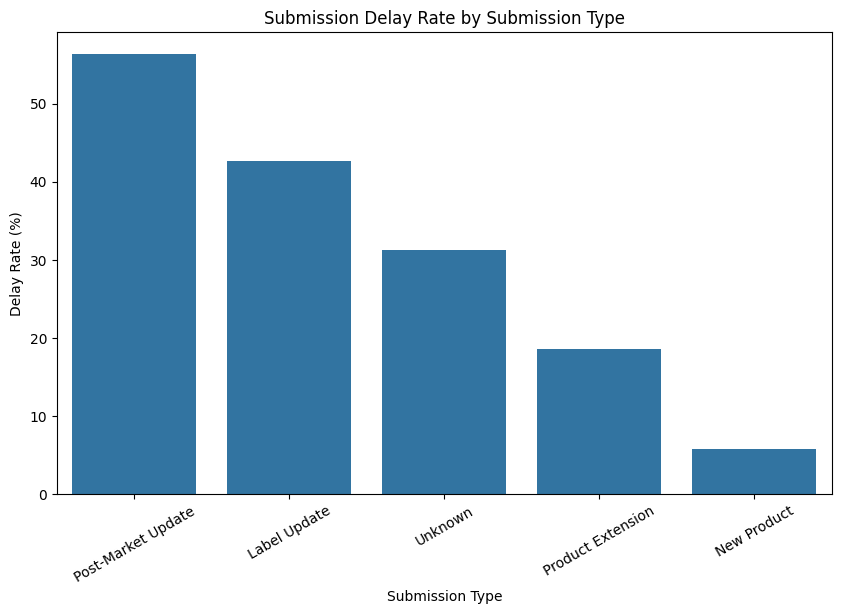

In [19]:
# visualise delay rates by submission type
plt.figure(figsize=(10, 6))

sns.barplot(
    x=delay_by_type.index,
    y=delay_by_type.values
)

plt.title("Submission Delay Rate by Submission Type")
plt.xlabel("Submission Type")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=30)

plt.show()

In [20]:
#Analyse review performance by region
submissions_region = submissions.merge(
    regions,
    on="Region_ID",
    how="left"
)

print(submissions_region[[
    "Region_ID",
    "Region"
]].drop_duplicates().sort_values("Region_ID"))

    Region_ID         Region
3           1             UK
12          2        Germany
4           3  United States
7           4         Canada
0           5         France
1           6    Netherlands
10          7      Australia
2           8      Singapore


In [21]:
#analyse regional performance
regional_performance = (
    submissions_region
    .groupby("Region")
    .agg(
        Total_Submissions=("Submission_ID", "count"),
        Avg_Review_Days=("Review_Days", "mean"),
        Approval_Rate=("Submission_Status", lambda x: (x == "Approved").mean() * 100),
        Delay_Rate=("Submission_Delayed", "mean"),
        Avg_Risk_Score=("Risk_Score", "mean")
    )
    .sort_values("Delay_Rate", ascending=False)
)

regional_performance["Delay_Rate"] = (
    regional_performance["Delay_Rate"] * 100
)

regional_performance.round(2)

,Total_Submissions,Avg_Review_Days,Approval_Rate,Delay_Rate,Avg_Risk_Score
Region,,,,,
Australia,2979,79.91,47.06,35.18,42.86
Germany,4282,77.74,49.42,30.43,43.09
France,3603,76.39,50.21,28.81,42.25
Canada,2621,75.82,52.50,27.78,43.52
Singapore,2988,75.26,52.64,26.64,42.74
UK,3933,73.69,55.20,23.29,42.65
Netherlands,2387,72.52,57.56,21.66,42.71
United States,7207,70.16,59.22,18.36,42.66


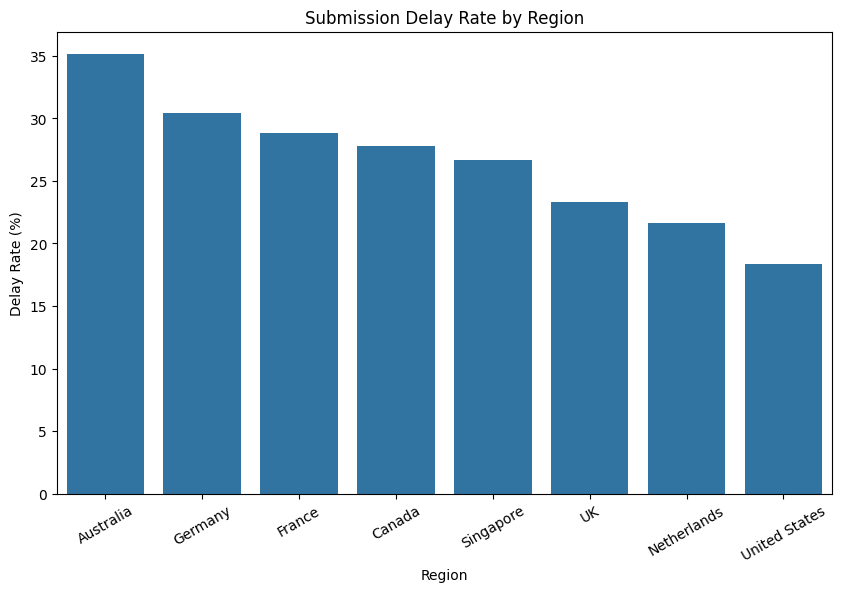

In [22]:
# visualise regional delay rates
plt.figure(figsize=(10, 6))

sns.barplot(
    x=regional_performance.index,
    y=regional_performance["Delay_Rate"].values
)

plt.title("Submission Delay Rate by Region")
plt.xlabel("Region")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=30)

plt.show()

In [23]:
#compare approval rates by region
approval_by_region = (
    submissions_region
    .groupby("Region")["Submission_Status"]
    .apply(lambda x: (x == "Approved").mean() * 100)
    .sort_values(ascending=False)
)

print(approval_by_region.round(2))

Region
United States    59.22
Netherlands      57.56
UK               55.20
Singapore        52.64
Canada           52.50
France           50.21
Germany          49.42
Australia        47.06
Name: Submission_Status, dtype: float64


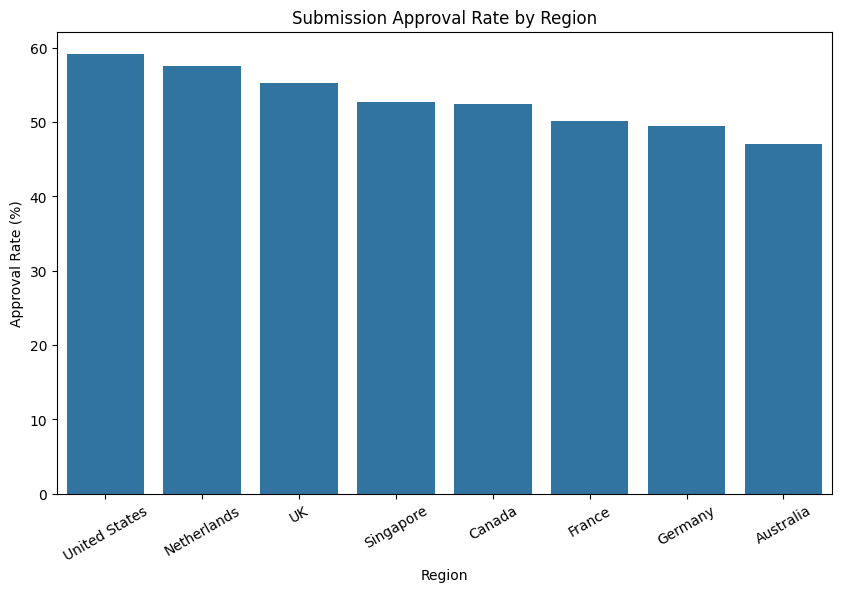

In [24]:
#Visualize approval rate by region
plt.figure(figsize=(10, 6))

sns.barplot(
    x=approval_by_region.index,
    y=approval_by_region.values
)

plt.title("Submission Approval Rate by Region")
plt.xlabel("Region")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=30)

plt.show()

In [25]:
#Analyze risk categories
review_by_risk = (
    submissions
    .groupby("Risk_Category")["Review_Days"]
    .mean()
    .sort_values(ascending=False)
)

print(review_by_risk.round(2))

Risk_Category
High      81.88
Unknow    76.12
Medium    75.75
Low       70.33
Name: Review_Days, dtype: float64


In [26]:
#Compare delay rates by risk category
delay_by_risk = (
    submissions
    .groupby("Risk_Category")["Submission_Delayed"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(delay_by_risk.round(2))

Risk_Category
High      38.70
Medium    27.19
Unknow    24.29
Low       18.42
Name: Submission_Delayed, dtype: float64


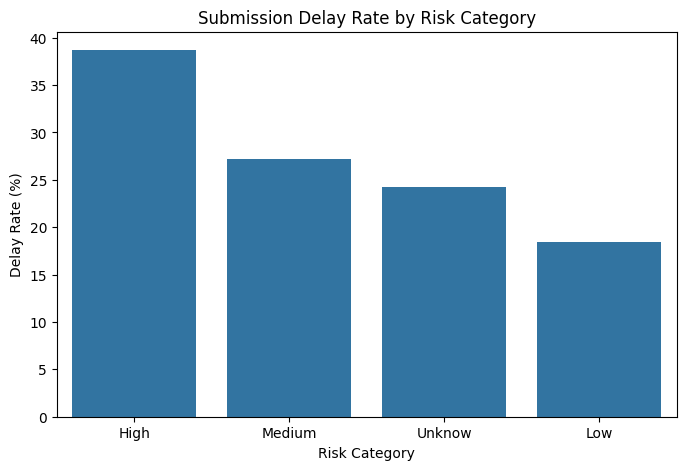

In [27]:
#Visualize delay rate by risk category
plt.figure(figsize=(8, 5))

sns.barplot(
    x=delay_by_risk.index,
    y=delay_by_risk.values
)

plt.title("Submission Delay Rate by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Delay Rate (%)")

plt.show()

In [28]:
#Compare approval rates by risk category
approval_by_risk = (
    submissions
    .groupby("Risk_Category")["Submission_Status"]
    .apply(lambda x: (x == "Approved").mean() * 100)
    .sort_values(ascending=False)
)

print(approval_by_risk.round(2))

Risk_Category
Unknow    61.43
Low       58.45
Medium    52.46
High      44.93
Name: Submission_Status, dtype: float64


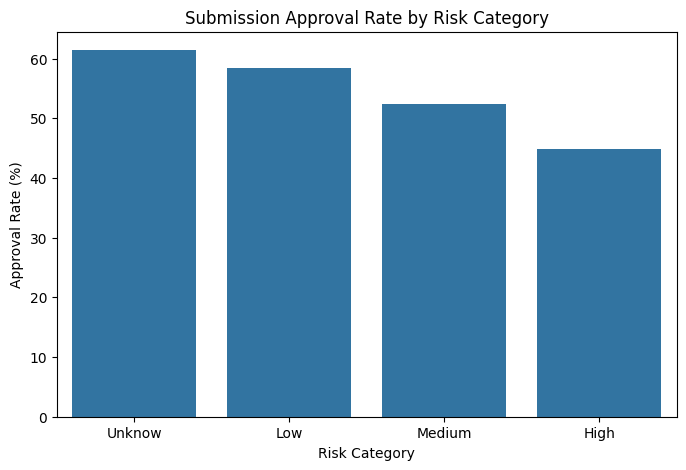

In [29]:
#Visualize approval rate by risk category
plt.figure(figsize=(8, 5))

sns.barplot(
    x=approval_by_risk.index,
    y=approval_by_risk.values
)

plt.title("Submission Approval Rate by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Approval Rate (%)")

plt.show()

In [30]:
#Analyze priority
review_by_priority = (
    submissions
    .groupby("Priority")["Review_Days"]
    .mean()
    .sort_values(ascending=False)
)

print(review_by_priority.round(2))

Priority
Critical    77.40
High        75.98
Medium      73.94
Low         72.35
Name: Review_Days, dtype: float64


In [31]:
#Compare delay rates by priority
delay_by_priority = (
    submissions
    .groupby("Priority")["Submission_Delayed"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(delay_by_priority.round(2))

Priority
Critical    30.55
High        27.92
Medium      24.34
Low         21.75
Name: Submission_Delayed, dtype: float64


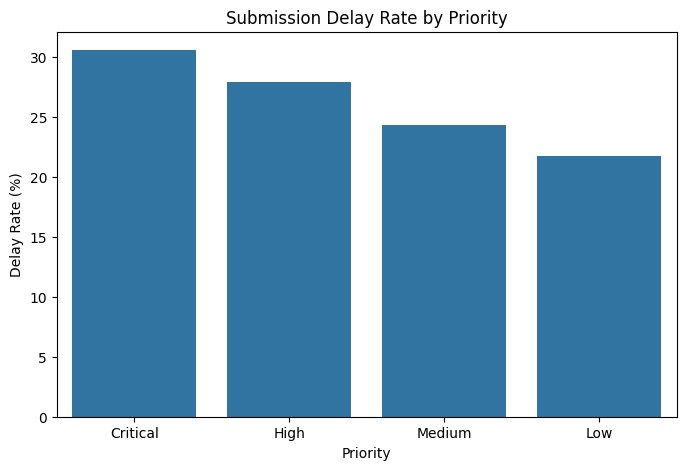

In [32]:
#Visualize priority delay rates
plt.figure(figsize=(8, 5))

sns.barplot(
    x=delay_by_priority.index,
    y=delay_by_priority.values
)

plt.title("Submission Delay Rate by Priority")
plt.xlabel("Priority")
plt.ylabel("Delay Rate (%)")

plt.show()

In [33]:
#Analyze the monthly trend
monthly_performance = (
    submissions
    .assign(Month=submissions["Submission_Date"].dt.to_period("M").astype(str))
    .groupby("Month")
    .agg(
        Total_Submissions=("Submission_ID", "count"),
        Avg_Review_Days=("Review_Days", "mean"),
        Approval_Rate=("Submission_Status", lambda x: (x == "Approved").mean() * 100),
        Delay_Rate=("Submission_Delayed", "mean")
    )
)

monthly_performance["Delay_Rate"] = (
    monthly_performance["Delay_Rate"] * 100
)

monthly_performance.round(2).head(10)

,Total_Submissions,Avg_Review_Days,Approval_Rate,Delay_Rate
Month,,,,
2023-01,873,73.92,53.61,26.23
2023-02,816,73.92,54.41,25.61
2023-03,916,76.12,52.51,27.40
2023-04,809,73.12,55.38,23.24
2023-05,847,74.30,52.42,25.38
2023-06,873,74.10,55.33,24.05
2023-07,836,74.05,52.27,27.15
2023-08,896,75.27,52.90,25.45
2023-09,802,74.94,49.50,27.93


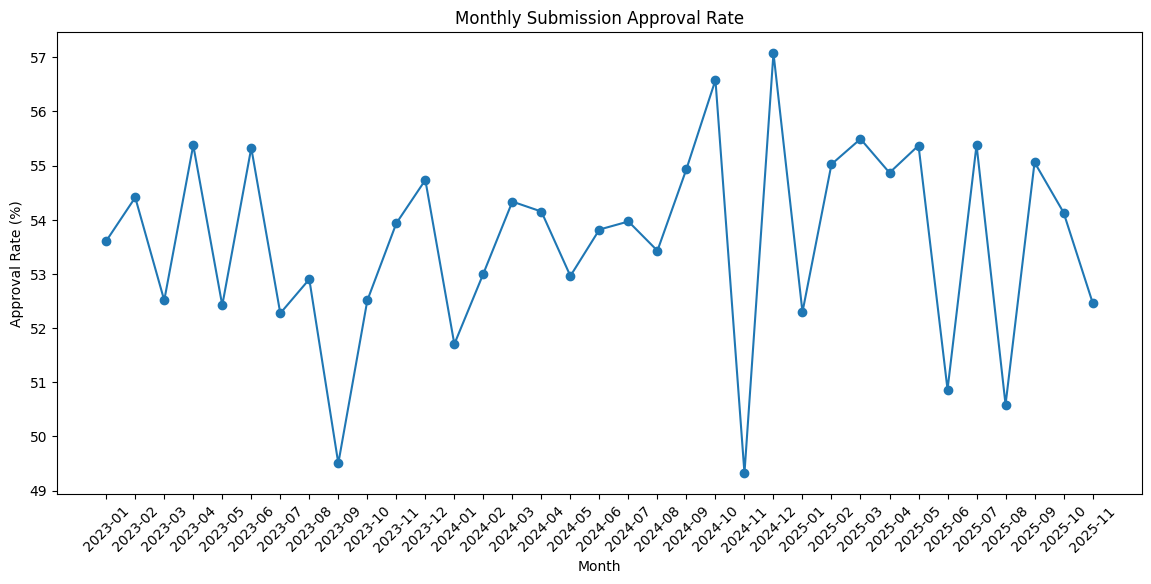

In [34]:
#visualise Monthly approval-rate trend
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance.index,
    monthly_performance["Approval_Rate"],
    marker="o"
)

plt.title("Monthly Submission Approval Rate")
plt.xlabel("Month")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=45)

plt.show()

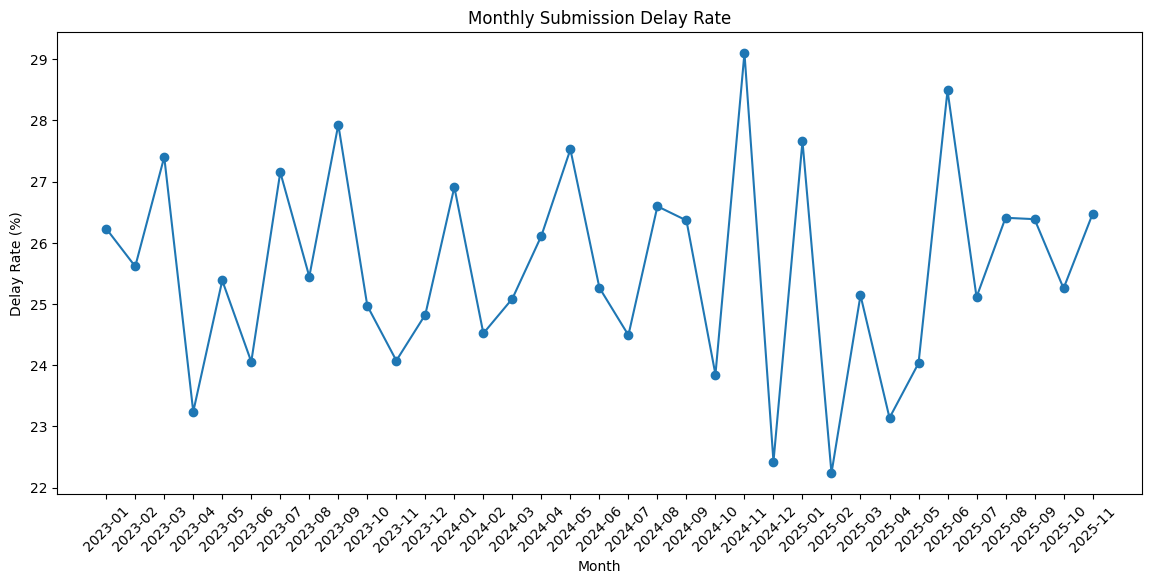

In [35]:
#visualise Monthly delay-rate trend
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance.index,
    monthly_performance["Delay_Rate"],
    marker="o"
)

plt.title("Monthly Submission Delay Rate")
plt.xlabel("Month")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [36]:
#Analyze the lifecycle events
lifecycle_stage_summary = (
    lifecycle_events
    .groupby("Lifecycle_Stage")["Stage_Duration_Days"]
    .agg(
        Total_Events="count",
        Avg_Duration_Days="mean"
    )
    .sort_values("Avg_Duration_Days", ascending=False)
)

print(lifecycle_stage_summary.round(2))

                        Total_Events  Avg_Duration_Days
Lifecycle_Stage                                        
Development                    30000             120.03
Post-Market Monitoring         30000              90.05
Regulatory Review              30000              74.61
Submission Preparation         30000              44.95
Approval                       30000              14.97
Regulatory Submission          30000              12.03


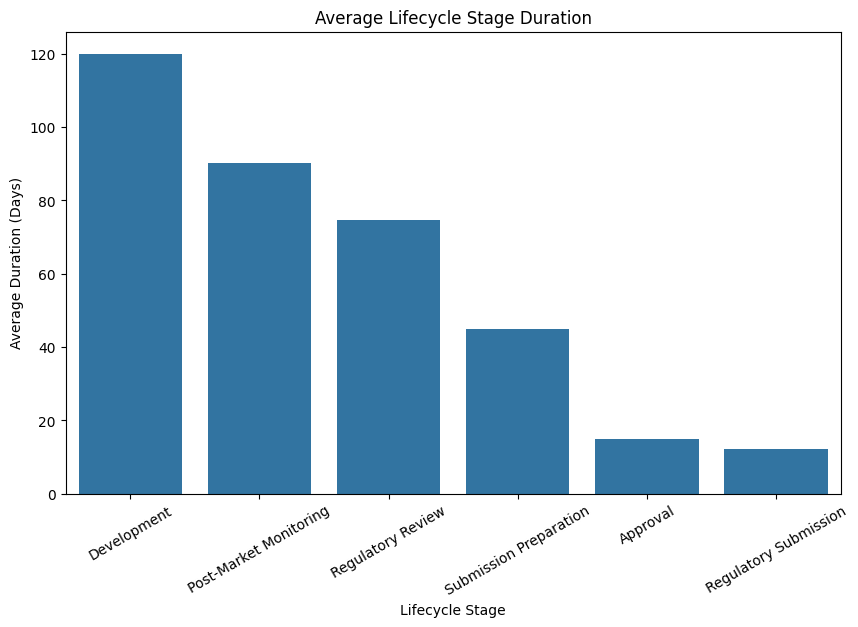

In [37]:
#Visualize lifecycle-stage duration
plt.figure(figsize=(10, 6))

sns.barplot(
    x=lifecycle_stage_summary.index,
    y=lifecycle_stage_summary["Avg_Duration_Days"]
)

plt.title("Average Lifecycle Stage Duration")
plt.xlabel("Lifecycle Stage")
plt.ylabel("Average Duration (Days)")
plt.xticks(rotation=30)

plt.show()

In [38]:
#Check lifecycle event status
lifecycle_events["Event_Status"].value_counts()

,count
Event_Status,
Completed,157298
In Progress,22702


In [39]:
#Check missing approval dates by status
approval_date_quality = (
    submissions
    .groupby("Submission_Status")
    .agg(
        Total_Submissions=("Submission_ID", "count"),
        Missing_Approval_Dates=("Approval_Date", lambda x: x.isna().sum())
    )
)

approval_date_quality["Missing_Rate"] = (
    approval_date_quality["Missing_Approval_Dates"]
    / approval_date_quality["Total_Submissions"]
    * 100
)

print(approval_date_quality.round(2))

                   Total_Submissions  Missing_Approval_Dates  Missing_Rate
Submission_Status                                                         
Approved                       16089                     825          5.13
Delayed                         4606                     236          5.12
Rejected                        1799                      80          4.45
Under Review                    6745                    6745        100.00
Withdrawn                        761                      32          4.20


In [40]:
#Calculate the overall data-quality impact
unexpected_missing_approval = submissions[
    (submissions["Submission_Status"] != "Under Review") &
    (submissions["Approval_Date"].isna())
]

print("Unexpected missing approval dates:", len(unexpected_missing_approval))
print(
    "Percentage of all submissions:",
    round(len(unexpected_missing_approval) / len(submissions) * 100, 2),
    "%"
)

Unexpected missing approval dates: 1173
Percentage of all submissions: 3.91 %


In [41]:
# checking unknown values
print("Unknown Submission Types:")
print(submissions["Submission_Type"].value_counts())

print("\nRisk Category values:")
print(submissions["Risk_Category"].value_counts())

Unknown Submission Types:
Submission_Type
New Product           10139
Product Extension      8452
Label Update           6494
Post-Market Update     4835
Unknown                  80
Name: count, dtype: int64

Risk Category values:
Risk_Category
Medium    14631
Low       11077
High       4222
Unknow       70
Name: count, dtype: int64


In [42]:
#Creating clean analysis categories
submissions["Submission_Type_Clean"] = (
    submissions["Submission_Type"].replace({
        "Unknown": np.nan
    })
)

submissions["Risk_Category_Clean"] = (
    submissions["Risk_Category"].replace({
        "Unknow": np.nan
    })
)

print("Clean columns created successfully")
print("Missing Submission Type:", submissions["Submission_Type_Clean"].isna().sum())
print("Missing Risk Category:", submissions["Risk_Category_Clean"].isna().sum())

Clean columns created successfully
Missing Submission Type: 80
Missing Risk Category: 70


In [43]:
#Creating a clean business-analysis dataset
clean_submissions = submissions.dropna(
    subset=["Submission_Type_Clean", "Risk_Category_Clean"]
).copy()

print("Original rows:", len(submissions))
print("Clean analysis rows:", len(clean_submissions))
print("Rows excluded:", len(submissions) - len(clean_submissions))

Original rows: 30000
Clean analysis rows: 29850
Rows excluded: 150


In [44]:
#Analyze the relationship between risk score and review time
correlation = clean_submissions[
    ["Risk_Score", "Review_Days"]
].corr()

print(correlation.round(3))

             Risk_Score  Review_Days
Risk_Score        1.000        0.177
Review_Days       0.177        1.000


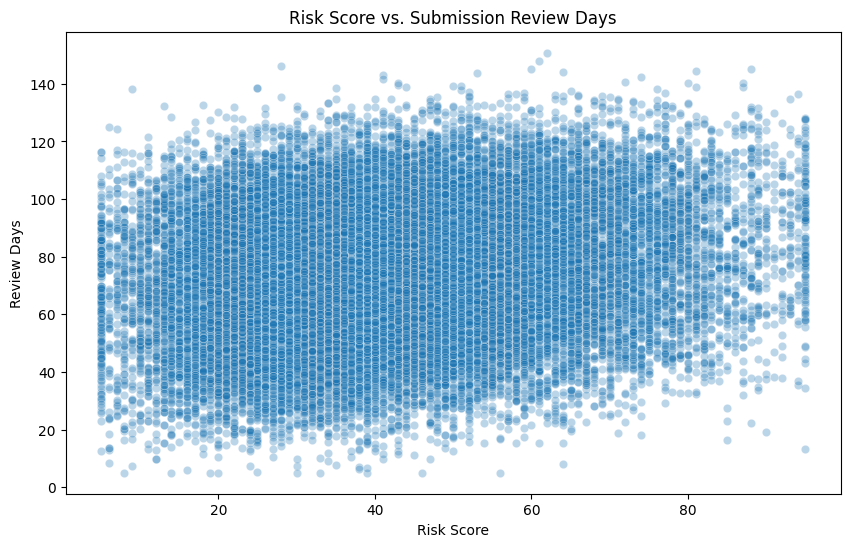

In [45]:
#visualise the relationship between risk score and review time
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_submissions,
    x="Risk_Score",
    y="Review_Days",
    alpha=0.3
)

plt.title("Risk Score vs. Submission Review Days")
plt.xlabel("Risk Score")
plt.ylabel("Review Days")
plt.show()

In [46]:
#Identify the highest-risk submissions
high_risk_submissions = (
    clean_submissions
    .sort_values(
        ["Risk_Score", "Review_Days"],
        ascending=[False, False]
    )
    [["Submission_ID", "Risk_Score", "Risk_Category",
      "Submission_Type_Clean", "Review_Days",
      "Target_Review_Days", "Submission_Delayed"]]
    .head(20)
)

high_risk_submissions

,Submission_ID,Risk_Score,Risk_Category,Submission_Type_Clean,Review_Days,Target_Review_Days,Submission_Delayed
433,500434,95,High,New Product,128.3,120,True
16935,516936,95,High,New Product,127.8,120,True
27155,527156,95,High,New Product,127.8,120,True
16169,516170,95,High,New Product,127.5,120,True
27279,527280,95,High,New Product,125.0,120,True
21646,521647,95,High,New Product,123.8,120,True
24567,524568,95,High,New Product,122.9,120,True
24111,524112,95,High,New Product,121.6,120,True
934,500935,95,High,New Product,119.2,120,False
25647,525648,95,High,New Product,119.2,120,False


In [50]:
#Create a risk-vs-delay summary
risk_delay_summary = (
    clean_submissions
    .groupby("Risk_Category_Clean")
    .agg(
        Total_Submissions=("Submission_ID", "count"),
        Avg_Risk_Score=("Risk_Score", "mean"),
        Avg_Review_Days=("Review_Days", "mean"),
        Delay_Rate=("Submission_Delayed", "mean")
    )
)

risk_delay_summary["Delay_Rate"] *= 100

risk_delay_summary.round(2)

,Total_Submissions,Avg_Risk_Score,Avg_Review_Days,Delay_Rate
Risk_Category_Clean,,,,
High,4207,74.87,81.90,38.72
Low,11043,24.09,70.34,18.40
Medium,14600,47.67,75.73,27.16


In [51]:
#Building the Region × Submission Type analysis
submissions_region["Submission_Type_Clean"] = (
    submissions_region["Submission_Type"].replace({"Unknown": np.nan})
)

print(submissions_region["Submission_Type_Clean"].value_counts(dropna=False))
region_type_analysis = (
    submissions_region[
        submissions_region["Submission_Type_Clean"].notna()
    ]
    .groupby(["Region", "Submission_Type_Clean"])
    .agg(
        Total_Submissions=("Submission_ID", "count"),
        Avg_Review_Days=("Review_Days", "mean"),
        Delay_Rate=("Submission_Delayed", "mean"),
        Approval_Rate=(
            "Submission_Status",
            lambda x: (x == "Approved").mean()
        )
    )
)

region_type_analysis["Delay_Rate"] *= 100
region_type_analysis["Approval_Rate"] *= 100

region_type_analysis = region_type_analysis.sort_values(
    "Delay_Rate",
    ascending=False
)

region_type_analysis.round(2).head(15)

Submission_Type_Clean
New Product           10139
Product Extension      8452
Label Update           6494
Post-Market Update     4835
NaN                      80
Name: count, dtype: int64


,,Total_Submissions,Avg_Review_Days,Delay_Rate,Approval_Rate
Region,Submission_Type_Clean,,,,
Australia,Post-Market Update,489,52.42,70.55,22.29
Germany,Post-Market Update,705,51.05,66.67,23.97
France,Post-Market Update,600,49.70,62.67,27.17
Singapore,Post-Market Update,457,48.66,59.96,29.54
Australia,Label Update,605,62.48,56.03,31.57
Canada,Post-Market Update,413,47.80,53.03,31.96
UK,Post-Market Update,632,46.14,52.69,34.49
Netherlands,Post-Market Update,410,45.74,49.51,38.29
Germany,Label Update,890,59.53,48.31,36.07


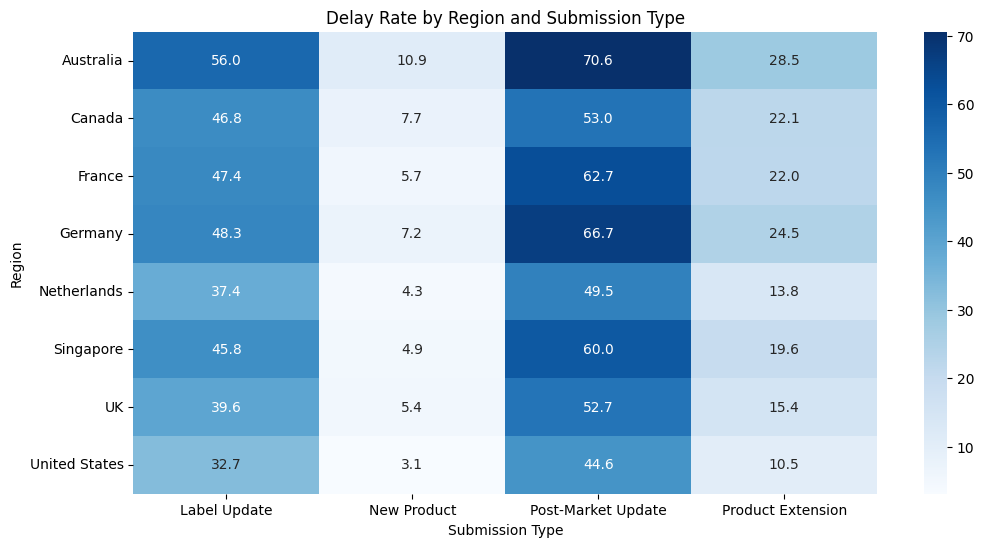

In [52]:
#Creating a heatmap of delay rates
heatmap_data = region_type_analysis["Delay_Rate"].unstack()

plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Delay Rate by Region and Submission Type")
plt.xlabel("Submission Type")
plt.ylabel("Region")
plt.show()

In [53]:
#creating the product-category mapping
products_enriched = products.merge(
    product_categories,
    on="Product_Category_ID",
    how="left"
)

print(products_enriched.shape)
print(products_enriched[[
    "Product_ID",
    "Product_Category",
    "Business_Unit",
    "Product_Type",
    "Lifecycle_Status",
    "Risk_Category"
]].head())


(15000, 9)
   Product_ID       Product_Category      Business_Unit Product_Type  \
0      100001  Laboratory Automation           Research    Component   
1      100002             Sequencing           Research  New Product   
2      100003      Research Reagents  Quality Assurance  New Product   
3      100004  Laboratory Automation        Diagnostics     Software   
4      100005  Molecular Diagnostics        Diagnostics     Platform   

  Lifecycle_Status Risk_Category  
0         Launched        Medium  
1         Launched        Medium  
2         Approved        Medium  
3       Submission          High  
4       Submission        Medium  


In [54]:
#Joining product information to submissions
submissions_enriched = submissions_region.merge(
    products_enriched[
        [
            "Product_ID",
            "Product_Category",
            "Business_Unit",
            "Product_Type",
            "Development_Date",
            "Lifecycle_Status"
        ]
    ],
    on="Product_ID",
    how="left"
)

print("Rows:", len(submissions_enriched))
print("Columns:", len(submissions_enriched.columns))
print(submissions_enriched.head())

Rows: 30000
Columns: 23
   Submission_ID  Product_ID  Region_ID     Submission_Type Submission_Date  \
0         500001      102969          5   Product Extension      2024-02-07   
1         500002      114850          6         New Product      2025-06-17   
2         500003      100622          8        Label Update      2025-07-10   
3         500004      104445          1         New Product      2025-03-14   
4         500005      108495          3  Post-Market Update      2025-03-27   

        Approval_Date Submission_Status Priority  Risk_Score Risk_Category  \
0                 NaT      Under Review   Medium          34           Low   
1                 NaT      Under Review     High          47        Medium   
2 2025-08-23 02:24:00          Approved      Low          18           Low   
3 2025-06-29 02:24:00          Approved   Medium          49        Medium   
4 2025-05-18 12:00:00           Delayed     High          47        Medium   

   ...  Review_Variance_Days  Re

In [55]:
#Analyze performance by product category
category_performance = (
    submissions_enriched
    .groupby("Product_Category")
    .agg(
        Total_Submissions=("Submission_ID", "count"),
        Avg_Review_Days=("Review_Days", "mean"),
        Delay_Rate=("Submission_Delayed", "mean"),
        Approval_Rate=(
            "Submission_Status",
            lambda x: (x == "Approved").mean()
        )
    )
)

category_performance["Delay_Rate"] *= 100
category_performance["Approval_Rate"] *= 100

category_performance = category_performance.sort_values(
    "Delay_Rate",
    ascending=False
)

category_performance.round(2)

,Total_Submissions,Avg_Review_Days,Delay_Rate,Approval_Rate
Product_Category,,,,
Laboratory Automation,4243,74.24,27.03,53.45
Molecular Diagnostics,6587,74.61,26.46,52.59
Bioinformatics,3689,75.29,26.10,52.91
Research Reagents,5155,74.21,24.77,53.79
Sample Preparation,5487,74.90,24.66,54.18
Sequencing,4839,74.52,24.51,54.95


In [56]:
#Analyze performance by Business Unit
business_unit_performance = (
    submissions_enriched
    .groupby("Business_Unit")
    .agg(
        Total_Submissions=("Submission_ID", "count"),
        Avg_Review_Days=("Review_Days", "mean"),
        Delay_Rate=("Submission_Delayed", "mean"),
        Approval_Rate=(
            "Submission_Status",
            lambda x: (x == "Approved").mean()
        )
    )
)

business_unit_performance["Delay_Rate"] *= 100
business_unit_performance["Approval_Rate"] *= 100

business_unit_performance = business_unit_performance.sort_values(
    "Delay_Rate",
    ascending=False
)

business_unit_performance.round(2)

,Total_Submissions,Avg_Review_Days,Delay_Rate,Approval_Rate
Business_Unit,,,,
Product Management,5966,74.55,26.38,52.51
Diagnostics,6106,74.83,25.86,53.23
Research,5912,74.56,25.44,53.48
Regulatory Affairs,5782,74.41,25.10,55.05
Quality Assurance,6234,74.69,25.04,53.91


In [57]:
#Analyze performance by regulatory area
regulatory_area_performance = (
    submissions_enriched
    .groupby("Regulatory_Area")
    .agg(
        Total_Submissions=("Submission_ID", "count"),
        Avg_Review_Days=("Review_Days", "mean"),
        Delay_Rate=("Submission_Delayed", "mean"),
        Approval_Rate=(
            "Submission_Status",
            lambda x: (x == "Approved").mean()
        )
    )
)

regulatory_area_performance["Delay_Rate"] *= 100
regulatory_area_performance["Approval_Rate"] *= 100

regulatory_area_performance = regulatory_area_performance.sort_values(
    "Delay_Rate",
    ascending=False
)

regulatory_area_performance.round(2)

,Total_Submissions,Avg_Review_Days,Delay_Rate,Approval_Rate
Regulatory_Area,,,,
TGA,2979,79.91,35.18,47.06
EU,10272,76.05,27.82,51.59
Health Canada,2621,75.82,27.78,52.50
HSA,2988,75.26,26.64,52.64
MHRA,3933,73.69,23.29,55.20
FDA,7207,70.16,18.36,59.22


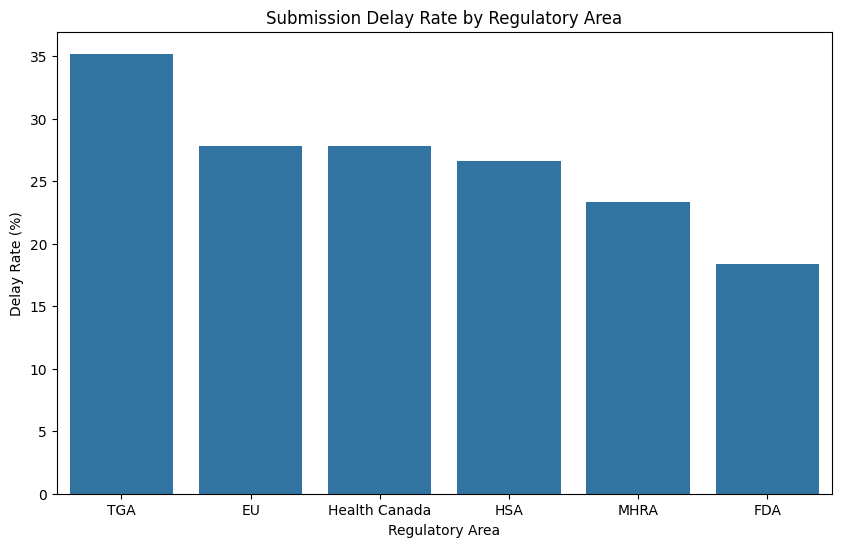

In [58]:
#Creating the final regulatory-area visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    data=regulatory_area_performance.reset_index(),
    x="Regulatory_Area",
    y="Delay_Rate"
)

plt.title("Submission Delay Rate by Regulatory Area")
plt.xlabel("Regulatory Area")
plt.ylabel("Delay Rate (%)")
plt.show()

In [59]:
#Creating the final Power BI dataset
powerbi_data = submissions_enriched.copy()

print("Rows:", len(powerbi_data))
print("Columns:", len(powerbi_data.columns))
print(powerbi_data.columns.tolist())


Rows: 30000
Columns: 23
['Submission_ID', 'Product_ID', 'Region_ID', 'Submission_Type', 'Submission_Date', 'Approval_Date', 'Submission_Status', 'Priority', 'Risk_Score', 'Risk_Category', 'Review_Days', 'Target_Review_Days', 'Submission_Delayed', 'Review_Variance_Days', 'Review_Within_Target', 'Region', 'Regulatory_Area', 'Submission_Type_Clean', 'Product_Category', 'Business_Unit', 'Product_Type', 'Development_Date', 'Lifecycle_Status']


In [60]:
#exporting the powe BI dataset
powerbi_data.to_csv(
    "/content/submissions_enriched.csv",
    index=False
)

print("File saved successfully.")

File saved successfully.
